# Bibliométrie Phase 1 — Corpus brut dédoublonné

**Objectif** : Analyse descriptive du corpus avant screening (Tri #1).  
**Input** : `data/processed/corpus_dedup_final.csv`  
**Output** : Figures dans `results/figures/` + données VOSviewer dans `results/tables/`

Conforme à Carrera Rivera et al. (2022) — Phase B, étape bibliométrique descriptive.

---

## 0. Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# ── Dossiers de sortie ────────────────────────────────────────────────────────
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/tables',  exist_ok=True)

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Blues_d', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

ACCENT  = '#2563EB'   # bleu principal
ACCENT2 = '#16A34A'   # vert secondaire
GRAY    = '#6B7280'

# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/corpus_dedup_final.csv', encoding='utf-8-sig')
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

print(f"Corpus chargé : {len(df)} articles")
print(f"Période       : {df['year'].min()} – {df['year'].max()}")
print(f"Colonnes      : {list(df.columns)}")

Corpus chargé : 1888 articles
Période       : 2020 – 2025
Colonnes      : ['title', 'abstract', 'authors', 'year', 'doi', 'source', 'keywords', 'doc_type', 'citations', 'database', 'query']


---
## 1. Rapport EDA — Vue d'ensemble

In [2]:
# ── Nettoyage doc_type ─────────────────────────────────────────────────────────
def normalise_doc_type(t):
    t = str(t).lower()
    if 'conference' in t or 'proceeding' in t: return 'Conference Paper'
    if 'journal' in t or 'article' in t:       return 'Journal Article'
    if 'preprint' in t:                         return 'Preprint'
    return 'Other'

df['doc_type_clean'] = df['doc_type'].apply(normalise_doc_type)

# ── Statistiques générales ─────────────────────────────────────────────────────
eda = {
    'Total articles'            : len(df),
    'Période couverte'          : f"{df['year'].min()} – {df['year'].max()}",
    'Articles avec abstract'    : df['abstract'].notna().sum(),
    'Articles sans abstract'    : df['abstract'].isna().sum(),
    'Articles avec DOI'         : (df['doi'] != '').sum(),
    'Articles sans DOI'         : (df['doi'] == '').sum(),
    'Bases de données'          : df['database'].nunique(),
    'Requêtes'                  : df['query'].nunique(),
    'Sources uniques (venues)'  : df['source'].nunique(),
    'Auteurs uniques (estimé)'  : df['authors'].str.split(';').explode().str.strip().nunique(),
}

eda_df = pd.DataFrame.from_dict(eda, orient='index', columns=['Valeur'])
eda_df.to_csv('../results/tables/eda_report.csv', encoding='utf-8-sig')

print("=== RAPPORT EDA ===")
print(eda_df.to_string())

=== RAPPORT EDA ===
                               Valeur
Total articles                   1888
Période couverte          2020 – 2025
Articles avec abstract           1886
Articles sans abstract              2
Articles avec DOI                1888
Articles sans DOI                   0
Bases de données                   12
Requêtes                           10
Sources uniques (venues)         1151
Auteurs uniques (estimé)         5643


---
## 2. Distribution temporelle des publications

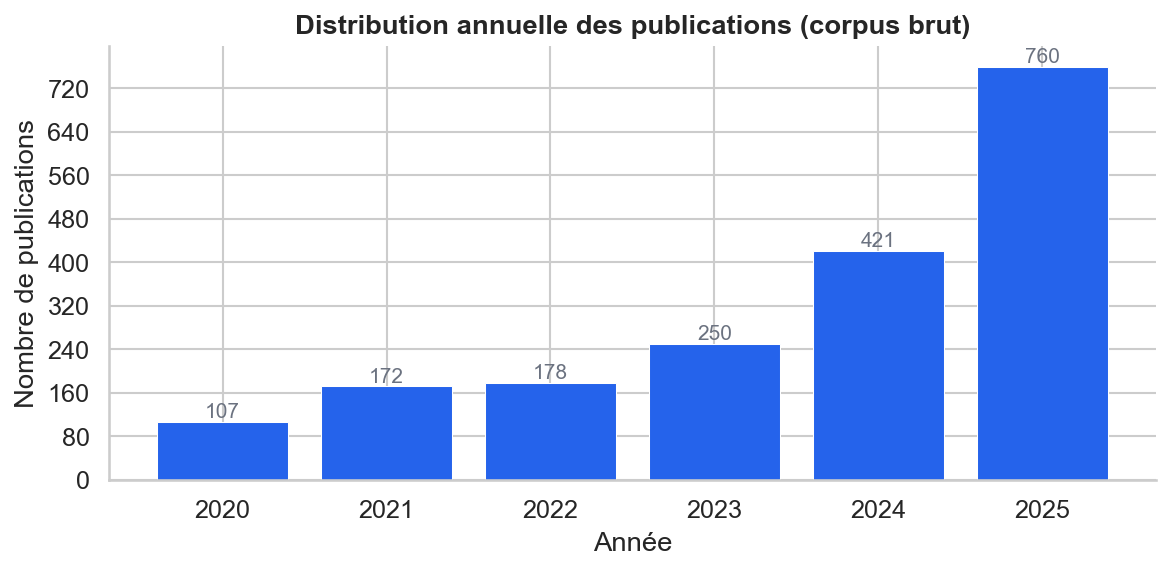

 year  count
 2020    107
 2021    172
 2022    178
 2023    250
 2024    421
 2025    760


In [ ]:
yearly = df.groupby('year').size().reset_index(name='count')
yearly = yearly[yearly['year'].between(2020, 2025)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(yearly['year'].astype(str), yearly['count'],
              color=ACCENT, edgecolor='white', linewidth=0.5)

# Valeurs au-dessus des barres
for bar, val in zip(bars, yearly['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10, color=GRAY)

ax.set_title('Annual distribution of publications (raw corpus)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of publications')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/fig1_distribution_temporelle.png')
plt.show()
print(yearly.to_string(index=False))

---
## 3. Répartition par base de données et par requête

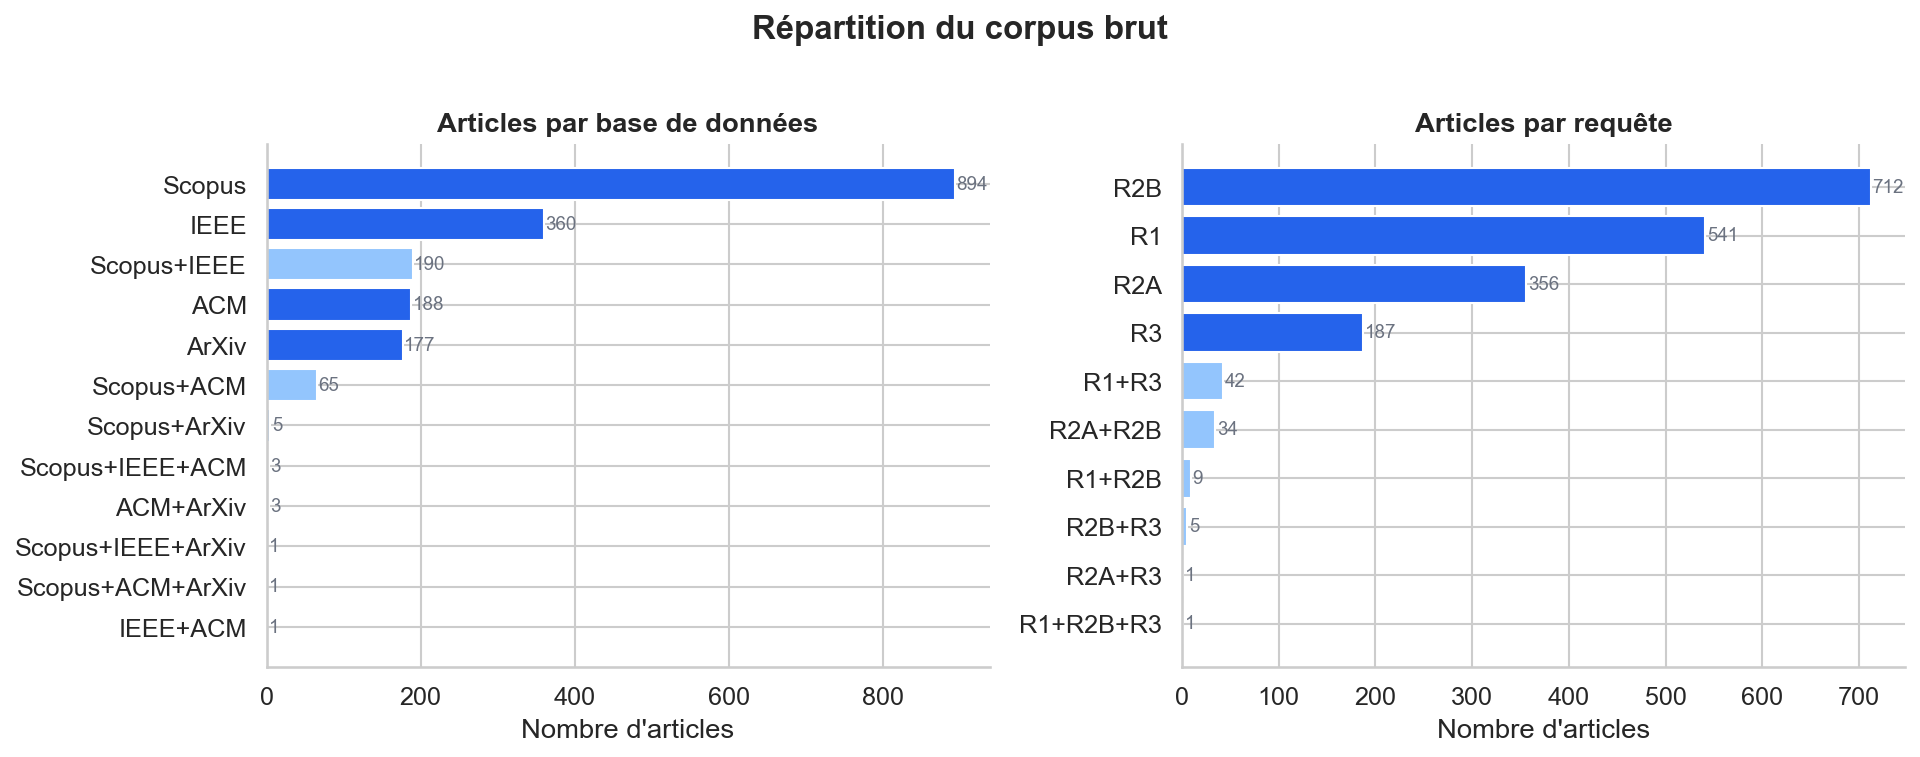

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Graph 1: by database ─────────────────────────────────────────────────────
db_counts = df['database'].value_counts()
colors_db = [ACCENT if '+' not in x else '#93C5FD' for x in db_counts.index]

axes[0].barh(db_counts.index, db_counts.values,
             color=colors_db, edgecolor='white')
for i, v in enumerate(db_counts.values):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9, color=GRAY)
axes[0].set_title('Articles by database', fontweight='bold')
axes[0].set_xlabel('Number of articles')
axes[0].invert_yaxis()
sns.despine(ax=axes[0])

# ── Graph 2: by query ────────────────────────────────────────────────────────
q_counts = df['query'].value_counts()
colors_q = [ACCENT if '+' not in x else '#93C5FD' for x in q_counts.index]

axes[1].barh(q_counts.index, q_counts.values,
             color=colors_q, edgecolor='white')
for i, v in enumerate(q_counts.values):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=9, color=GRAY)
axes[1].set_title('Articles by query', fontweight='bold')
axes[1].set_xlabel('Number of articles')
axes[1].invert_yaxis()
sns.despine(ax=axes[1])

plt.suptitle('Raw corpus distribution', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/fig2_repartition_bases_requetes.png')
plt.show()

---
## 4. Top 15 venues (journaux et conférences)

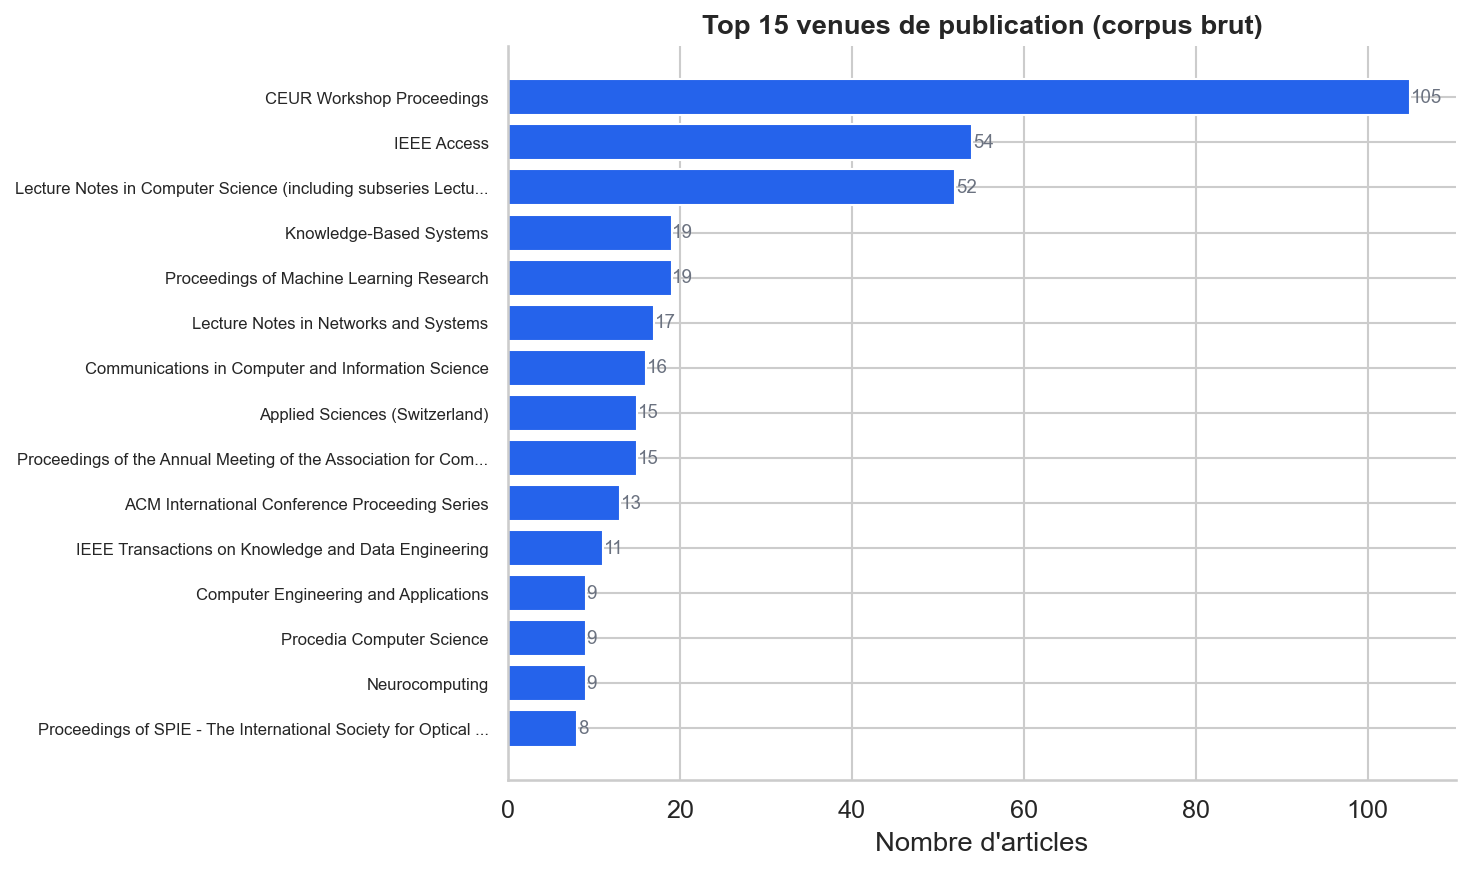

In [ ]:
# Exclure les sources vides et nettoyer
venues = df[df['source'].notna() & (df['source'] != '')]['source']
top_venues = venues.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_venues.index[::-1], top_venues.values[::-1],
               color=ACCENT, edgecolor='white')

for bar, val in zip(bars, top_venues.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color=GRAY)

ax.set_title('Top 15 publication venues (raw corpus)', fontweight='bold')
ax.set_xlabel('Number of articles')

# Tronquer les noms trop longs
labels = [l[:60] + '...' if len(l) > 60 else l for l in top_venues.index[::-1]]
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/fig3_top_venues.png')
plt.show()

# Exporter le tableau complet
top_venues.reset_index().rename(columns={'index':'venue','source':'count'}).to_csv(
    '../results/tables/top_venues.csv', index=False, encoding='utf-8-sig')

---
## 5. Top 15 auteurs productifs

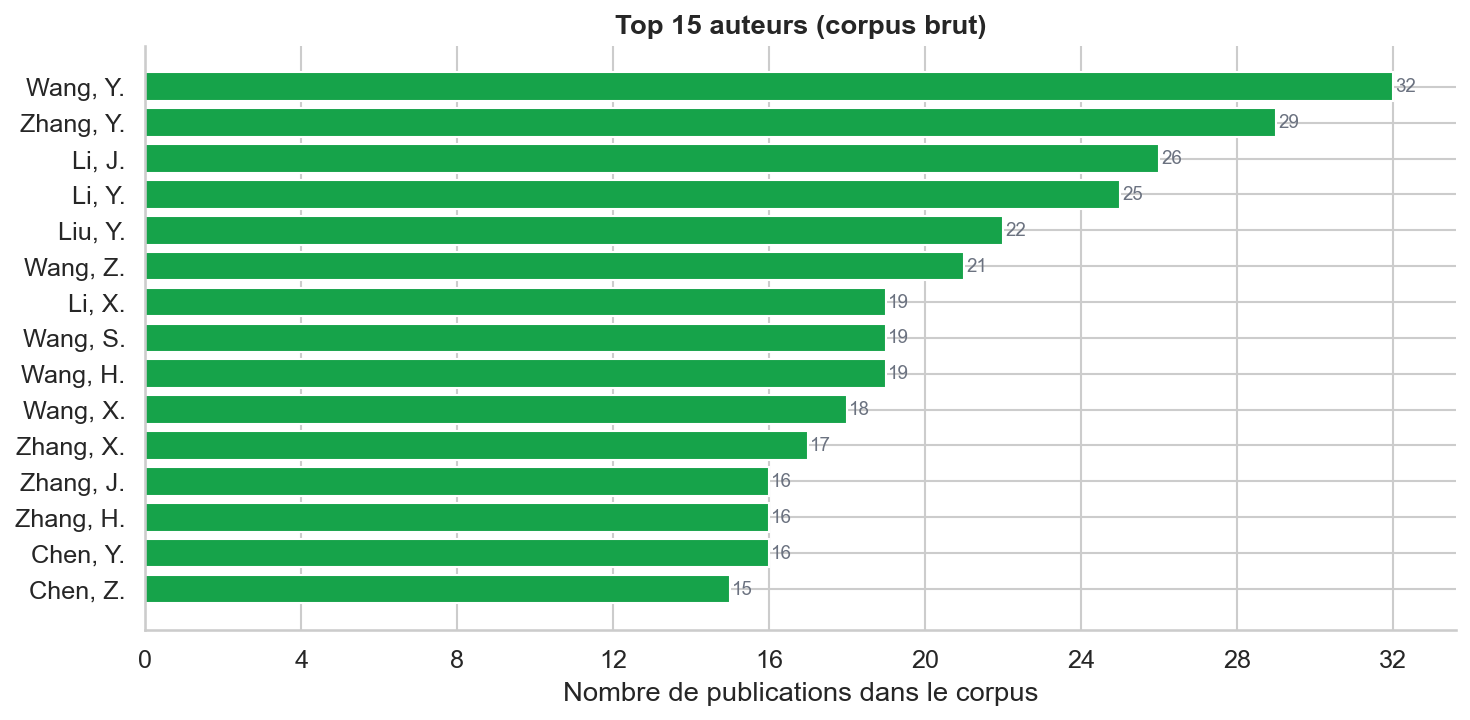

In [ ]:
# Exploser les auteurs (séparés par ';')
authors_series = (
    df['authors']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
)
top_authors = authors_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=ACCENT2, edgecolor='white')

for bar, val in zip(bars, top_authors.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color=GRAY)

ax.set_title('Top 15 authors (raw corpus)', fontweight='bold')
ax.set_xlabel('Number of publications in corpus')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/fig4_top_auteurs.png')
plt.show()

top_authors.reset_index().rename(
    columns={'index':'auteur','authors':'count'}).to_csv(
    '../results/tables/top_auteurs.csv', index=False, encoding='utf-8-sig')

---
## 6. Analyse des mots-clés auteurs — fréquence

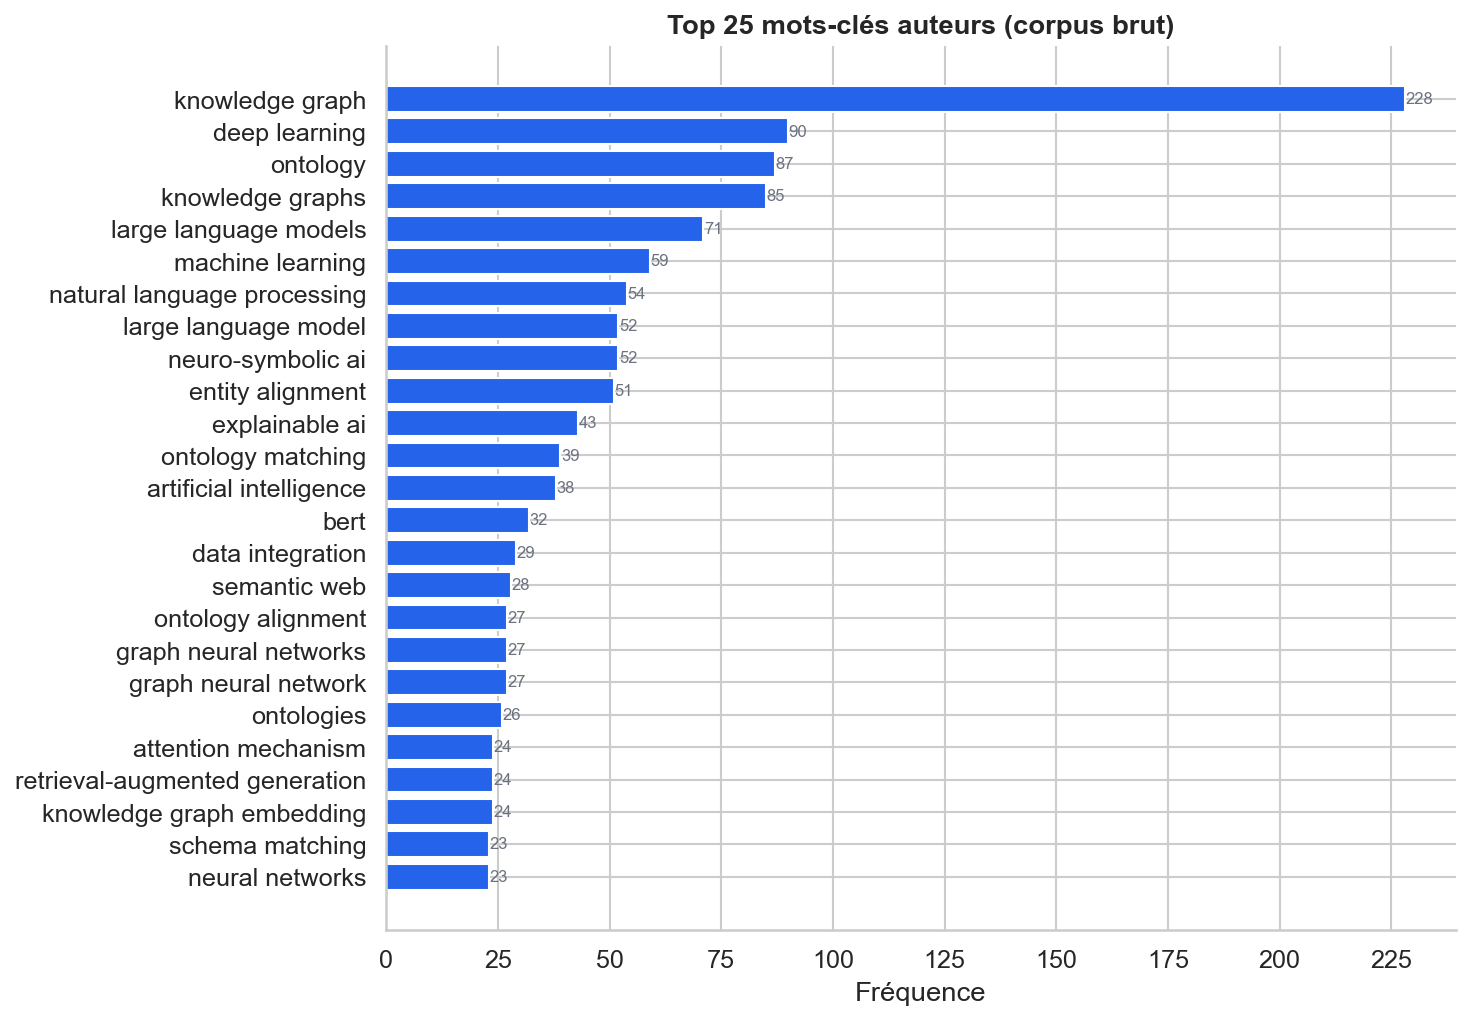

Mots-clés uniques exportés pour VOSviewer : 3993


In [ ]:
# Exploser et nettoyer les mots-clés
kw_series = (
    df['keywords']
    .dropna()
    .str.lower()
    .str.split(r'[;|]')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
)

top_kw = kw_series.value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_kw.index[::-1], top_kw.values[::-1],
               color=ACCENT, edgecolor='white')

for bar, val in zip(bars, top_kw.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8, color=GRAY)

ax.set_title('Top 25 author keywords (raw corpus)', fontweight='bold')
ax.set_xlabel('Frequency')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/fig5_top_keywords.png')
plt.show()

# Export pour VOSviewer (format attendu : term, occurrences)
top_kw_all = kw_series.value_counts().reset_index()
top_kw_all.columns = ['term', 'occurrences']
top_kw_all.to_csv('../results/tables/keywords_for_vosviewer.csv',
                  index=False, encoding='utf-8-sig')
print(f"Unique keywords exported for VOSviewer: {len(top_kw_all)}")

---
## 7. Évolution temporelle par requête

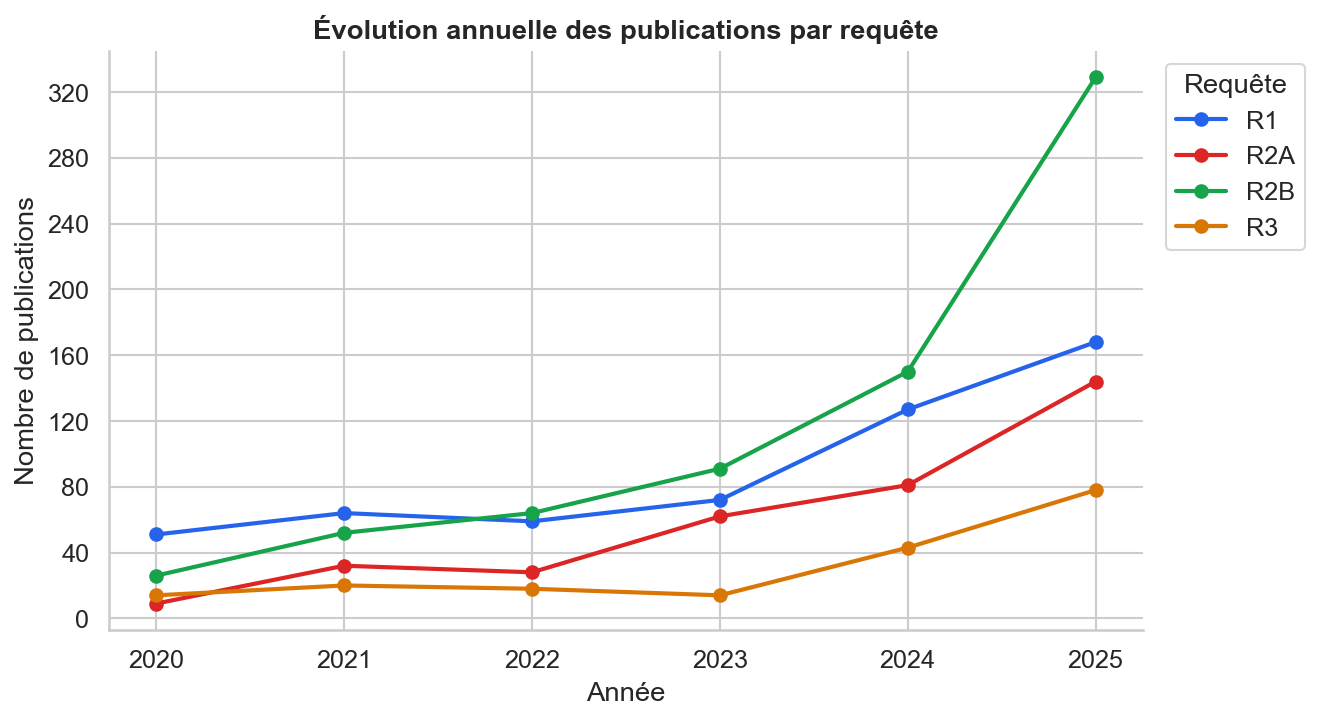

In [ ]:
# Garder seulement les requêtes simples (pas les combinaisons R1+R2A etc.)
df_simple_q = df[~df['query'].str.contains('\+', na=False)].copy()

pivot = (
    df_simple_q
    .groupby(['year', 'query'])
    .size()
    .unstack(fill_value=0)
    .loc[2020:2025]
)

colors_lines = [ACCENT, '#DC2626', ACCENT2, '#D97706']

fig, ax = plt.subplots(figsize=(9, 5))
for col, color in zip(pivot.columns, colors_lines):
    ax.plot(pivot.index.astype(str), pivot[col],
            marker='o', label=col, color=color, linewidth=2)

ax.set_title('Annual publication trend by query', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of publications')
ax.legend(title='Query', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/fig6_evolution_par_requete.png')
plt.show()

---
## 8. Chevauchements inter-bases — matrice de recouvrement

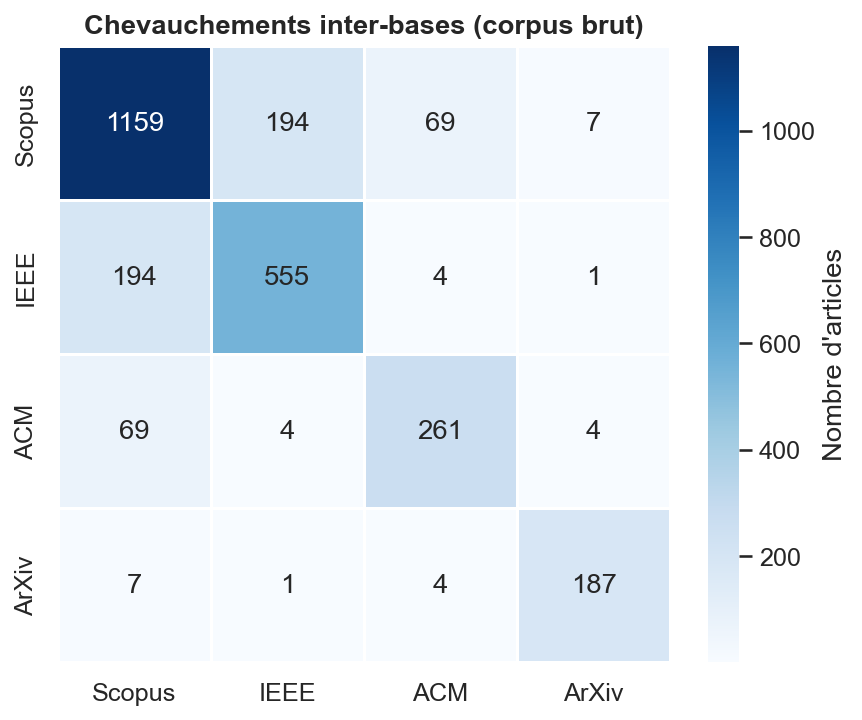

        Scopus  IEEE  ACM  ArXiv
Scopus    1159   194   69      7
IEEE       194   555    4      1
ACM         69     4  261      4
ArXiv        7     1    4    187


In [ ]:
bases = ['Scopus', 'IEEE', 'ACM', 'ArXiv']

# Créer une matrice de co-occurrence
matrix = pd.DataFrame(0, index=bases, columns=bases)

for _, row in df.iterrows():
    dbs = str(row['database']).split('+')
    for b in dbs:
        if b in bases:
            matrix.loc[b, b] += 1   # diagonal = articles de cette base
    if len(dbs) > 1:
        for i, b1 in enumerate(dbs):
            for b2 in dbs[i+1:]:
                if b1 in bases and b2 in bases:
                    matrix.loc[b1, b2] += 1
                    matrix.loc[b2, b1] += 1

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of articles'})
ax.set_title('Cross-database overlap (raw corpus)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/fig7_chevauchements_bases.png')
plt.show()

matrix.to_csv('../results/tables/overlap_matrix.csv', encoding='utf-8-sig')
print(matrix)

---
## 9. Export VOSviewer — co-occurrence de mots-clés

Le fichier `keywords_for_vosviewer.csv` généré à l'étape 6 peut être importé  
directement dans VOSviewer : **Create map → Based on bibliographic data →  
Read data from bibliographic database files → select CSV**.

Pour une co-occurrence réseau, VOSviewer a besoin du corpus complet en format  
BibTeX. Le bloc suivant exporte un `.bib` depuis ton corpus unifié.

In [14]:
def row_to_ris(idx, row):
    """Convertit une ligne du corpus en entrée RIS pour VOSviewer."""
    
    # Type de document
    if 'conference' in str(row['doc_type']).lower():
        ris_type = 'CONF'
    elif 'preprint' in str(row['doc_type']).lower():
        ris_type = 'UNPB'
    else:
        ris_type = 'JOUR'
    
    lines = [f'TY  - {ris_type}']
    
    if pd.notna(row['title'])    and row['title']:    
        lines.append(f'TI  - {row["title"]}')
    if pd.notna(row['year'])     and row['year']:     
        lines.append(f'PY  - {str(row["year"])}')
    if pd.notna(row['source'])   and row['source']:   
        lines.append(f'JO  - {row["source"]}')
    if pd.notna(row['doi'])      and row['doi']:      
        lines.append(f'DO  - {row["doi"]}')
    if pd.notna(row['abstract']) and row['abstract']: 
        lines.append(f'AB  - {str(row["abstract"])[:2000]}')
    if pd.notna(row['keywords']) and row['keywords']:
        for kw in str(row['keywords']).split(';'):
            kw = kw.strip()
            if kw:
                lines.append(f'KW  - {kw}')
    if pd.notna(row['authors'])  and row['authors']:
        for author in str(row['authors']).split(';'):
            author = author.strip()
            if author:
                lines.append(f'AU  - {author}')
    
    lines.append('ER  - ')
    return '\n'.join(lines)

# Générer le RIS
ris_entries = [row_to_ris(i, row) for i, row in df.iterrows()]
ris_content = '\n\n'.join(ris_entries)

path_ris = '../results/tables/corpus_vosviewer.ris'
with open(path_ris, 'w', encoding='utf-8') as f:
    f.write(ris_content)

print(f"✓ Export RIS : {len(df)} entrées")
print(f"  Fichier : {path_ris}")

✓ Export RIS : 1888 entrées
  Fichier : ../results/tables/corpus_vosviewer.ris


---
## 10. Résumé des outputs générés

In [13]:
print("=" * 55)
print("BIBLIOMÉTRIE PHASE 1 — OUTPUTS GÉNÉRÉS")
print("=" * 55)
print()
print("📊 FIGURES (results/figures/)")
print("  fig1_distribution_temporelle.png")
print("  fig2_repartition_bases_requetes.png")
print("  fig3_top_venues.png")
print("  fig4_top_auteurs.png")
print("  fig5_top_keywords.png")
print("  fig6_evolution_par_requete.png")
print("  fig7_chevauchements_bases.png")
print()
print("📋 TABLEAUX (results/tables/)")
print("  eda_report.csv              ← rapport EDA complet")
print("  top_venues.csv              ← top journaux/conférences")
print("  top_auteurs.csv             ← top auteurs")
print("  keywords_for_vosviewer.csv  ← fréquences mots-clés")
print("  overlap_matrix.csv          ← chevauchements bases")
print("  corpus_vosviewer.bib        ← import VOSviewer réseau")
print("  prisma_counts.xlsx          ← comptages PRISMA")
print()
print(f"Corpus analysé : {len(df)} articles")
print("Prochaine étape : Screening Tri #1 (titre/résumé)")

BIBLIOMÉTRIE PHASE 1 — OUTPUTS GÉNÉRÉS

📊 FIGURES (results/figures/)
  fig1_distribution_temporelle.png
  fig2_repartition_bases_requetes.png
  fig3_top_venues.png
  fig4_top_auteurs.png
  fig5_top_keywords.png
  fig6_evolution_par_requete.png
  fig7_chevauchements_bases.png

📋 TABLEAUX (results/tables/)
  eda_report.csv              ← rapport EDA complet
  top_venues.csv              ← top journaux/conférences
  top_auteurs.csv             ← top auteurs
  keywords_for_vosviewer.csv  ← fréquences mots-clés
  overlap_matrix.csv          ← chevauchements bases
  corpus_vosviewer.bib        ← import VOSviewer réseau
  prisma_counts.xlsx          ← comptages PRISMA

Corpus analysé : 1888 articles
Prochaine étape : Screening Tri #1 (titre/résumé)
